<a href="https://colab.research.google.com/github/ajsarsva/video-captioning-thesis/blob/main/notebooks/25_caption_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, shutil
os.makedirs('/root/.kaggle', exist_ok=True)
shutil.copy('/content/drive/MyDrive/kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

if os.path.exists('/content/video-captioning-thesis'):
    %cd /content/video-captioning-thesis
    !git pull origin main
else:
    !git clone https://github.com/ajsarsva/video-captioning-thesis.git
    %cd /content/video-captioning-thesis

import sys
sys.path.append('/content/video-captioning-thesis/src')

print("✅ Ready!")

Mounted at /content/drive
Cloning into 'video-captioning-thesis'...
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (103/103), done.
remote: Total 117 (delta 64), reused 27 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (117/117), 19.94 MiB | 14.40 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/video-captioning-thesis
✅ Ready!


Setup and Load Data

In [2]:
import json
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import re
import os

# Load all captions
with open('/content/drive/MyDrive/thesis-data/captions/strategy_A_full.json') as f:
    results_a = json.load(f)
with open('/content/drive/MyDrive/thesis-data/captions/strategy_B_full.json') as f:
    results_b = json.load(f)
with open('/content/drive/MyDrive/thesis-data/captions/strategy_C_full.json') as f:
    results_c = json.load(f)
with open('/content/drive/MyDrive/thesis-data/captions/strategy_Aplus_1000.json') as f:
    results_aplus = json.load(f)
with open('/content/drive/MyDrive/thesis-data/captions/strategy_Bplus_1000.json') as f:
    results_bplus = json.load(f)
with open('/content/drive/MyDrive/thesis-data/captions/strategy_Cplus_1000.json') as f:
    results_cplus = json.load(f)

# Load ground truth
with open('/content/drive/MyDrive/thesis-data/MSR_VTT.json') as f:
    gt_data = json.load(f)

ground_truth = {}
for ann in gt_data['annotations']:
    vid = ann['image_id']
    if vid not in ground_truth:
        ground_truth[vid] = []
    ground_truth[vid].append(ann['caption'])

# Use same 250 video IDs for fair comparison
with open('/content/drive/MyDrive/thesis-data/results/fusion_sample_ids.json') as f:
    sample_ids = json.load(f)[:250]

# All strategies in one dict for easy iteration
all_strategies = {
    'A (Uniform)':     results_a,
    'B (SSIM)':        results_b,
    'C (CLIP)':        results_c,
    'A+ (Uniform+T5)': results_aplus,
    'B+ (SSIM+T5)':    results_bplus,
    'C+ (CLIP+T5)':    results_cplus,
}

print(f"Videos loaded: {len(sample_ids)}")
print(f"Strategies: {list(all_strategies.keys())}")
print("✅ Data loaded!")

Videos loaded: 250
Strategies: ['A (Uniform)', 'B (SSIM)', 'C (CLIP)', 'A+ (Uniform+T5)', 'B+ (SSIM+T5)', 'C+ (CLIP+T5)']
✅ Data loaded!


### Caption Length Analysis ###

In [3]:
# ══════════════════════════════════════════════════════
# IDEA 3 — Caption Length and Vocabulary Analysis
# ══════════════════════════════════════════════════════

def get_captions(results, video_ids):
    """Extract valid captions for given video IDs."""
    caps = []
    for vid in video_ids:
        if vid in results:
            cap = results[vid].get('caption', '').strip()
            if cap:
                caps.append(cap)
    return caps


# Compute stats for each strategy
length_stats = {}

print("=" * 65)
print("CAPTION LENGTH ANALYSIS")
print("=" * 65)
print(f"{'Strategy':<20} {'Avg Words':>10} {'Min':>6} "
      f"{'Max':>6} {'Std Dev':>8}")
print("-" * 65)

for name, results in all_strategies.items():
    captions = get_captions(results, sample_ids)
    lengths = [len(cap.split()) for cap in captions]

    stats = {
        'mean':   round(np.mean(lengths), 2),
        'min':    int(np.min(lengths)),
        'max':    int(np.max(lengths)),
        'std':    round(np.std(lengths), 2),
        'median': round(np.median(lengths), 2),
        'captions': captions,
        'lengths': lengths
    }
    length_stats[name] = stats

    print(f"{name:<20} {stats['mean']:>10} {stats['min']:>6} "
          f"{stats['max']:>6} {stats['std']:>8}")

print("=" * 65)

# Reference caption length for comparison
ref_lengths = []
for vid in sample_ids:
    refs = ground_truth.get(vid, [])
    for r in refs:
        ref_lengths.append(len(r.split()))

print(f"\nReference captions avg length: {np.mean(ref_lengths):.2f} words")

CAPTION LENGTH ANALYSIS
Strategy              Avg Words    Min    Max  Std Dev
-----------------------------------------------------------------
A (Uniform)                9.71      4     49      4.2
B (SSIM)                   9.41      3     50     5.04
C (CLIP)                   9.59      1     49     3.98
A+ (Uniform+T5)           16.34      5     39     7.72
B+ (SSIM+T5)              15.25      5     40      7.2
C+ (CLIP+T5)              16.48      6     49      7.2

Reference captions avg length: 9.21 words


Vocabulary Diversity Analysis

In [4]:
# Type-Token Ratio — higher = more diverse vocabulary
def compute_ttr(captions):
    """Type-Token Ratio: unique words / total words."""
    all_words = []
    for cap in captions:
        words = cap.lower().split()
        all_words.extend(words)
    if not all_words:
        return 0, 0, 0
    total = len(all_words)
    unique = len(set(all_words))
    ttr = unique / total
    return round(ttr, 4), unique, total


print("=" * 65)
print("VOCABULARY DIVERSITY ANALYSIS")
print("=" * 65)
print(f"{'Strategy':<20} {'TTR':>8} {'Unique Words':>14} "
      f"{'Total Words':>12}")
print("-" * 65)

vocab_stats = {}
for name, results in all_strategies.items():
    captions = get_captions(results, sample_ids)
    ttr, unique, total = compute_ttr(captions)
    vocab_stats[name] = {
        'ttr': ttr,
        'unique': unique,
        'total': total
    }
    print(f"{name:<20} {ttr:>8.4f} {unique:>14} {total:>12}")

print("=" * 65)
print("\nHigher TTR = more diverse vocabulary")

# Reference TTR
ref_caps = []
for vid in sample_ids:
    refs = ground_truth.get(vid, [])
    ref_caps.extend(refs)
ref_ttr, ref_unique, ref_total = compute_ttr(ref_caps)
print(f"\nReference captions TTR: {ref_ttr:.4f} "
      f"({ref_unique} unique / {ref_total} total)")

VOCABULARY DIVERSITY ANALYSIS
Strategy                  TTR   Unique Words  Total Words
-----------------------------------------------------------------
A (Uniform)            0.1771            430         2428
B (SSIM)               0.1671            393         2352
C (CLIP)               0.1819            436         2397
A+ (Uniform+T5)        0.1535            627         4085
B+ (SSIM+T5)           0.1474            562         3813
C+ (CLIP+T5)           0.1517            625         4119

Higher TTR = more diverse vocabulary

Reference captions TTR: 0.0888 (4089 unique / 46058 total)


 Most Common Words Per Strategy

In [5]:
# Common words to exclude (stopwords)
stopwords = {
    'a', 'an', 'the', 'is', 'are', 'of', 'in', 'on', 'with',
    'and', 'to', 'at', 'by', 'for', 'as', 'it', 'its', 'this',
    'that', 'there', 'there\'s', 'be', 'been', 'being', 'was',
    'were', 'has', 'have', 'had', 's', 'from', 'into', 'while'
}

print("TOP 10 CONTENT WORDS PER STRATEGY")
print("=" * 65)

top_words = {}
for name, results in all_strategies.items():
    captions = get_captions(results, sample_ids)
    all_words = []
    for cap in captions:
        words = re.findall(r'\b[a-z]+\b', cap.lower())
        all_words.extend([w for w in words if w not in stopwords
                          and len(w) > 2])
    counter = Counter(all_words)
    top10 = counter.most_common(10)
    top_words[name] = top10
    words_str = ', '.join([f"{w}({c})" for w, c in top10])
    print(f"\n{name}:")
    print(f"  {words_str}")

print("\n" + "=" * 65)

TOP 10 CONTENT WORDS PER STRATEGY

A (Uniform):
  man(72), woman(55), standing(43), minecraft(35), sitting(27), person(21), white(21), group(21), black(19), table(18)

B (SSIM):
  man(90), sims(51), woman(44), standing(32), person(31), black(29), white(26), sitting(24), shirt(21), che(20)

C (CLIP):
  man(82), woman(45), standing(44), sims(29), minecraft(26), group(21), sitting(20), person(19), black(17), screen(17)

A+ (Uniform+T5):
  man(151), woman(75), standing(65), sitting(43), black(37), shirt(31), suit(28), person(28), group(28), room(25)

B+ (SSIM+T5):
  man(139), woman(74), standing(55), sitting(39), white(33), black(32), group(31), shirt(31), person(27), minecraft(27)

C+ (CLIP+T5):
  man(151), woman(85), standing(55), minecraft(44), tram(43), sitting(39), group(29), holding(29), black(28), people(27)



Plot Caption Length Comparison

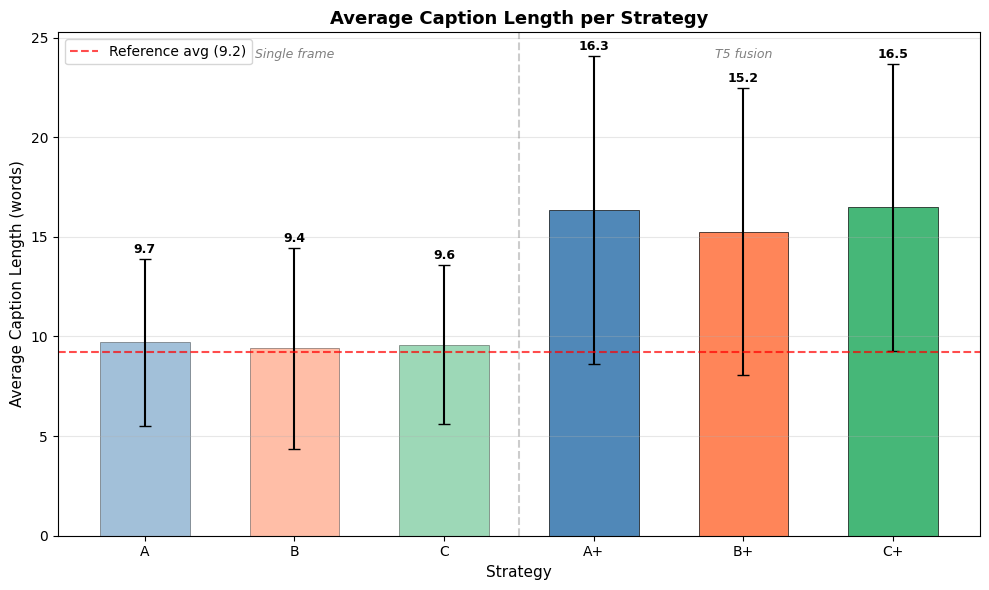

✅ Plot 1 saved: caption_length.png


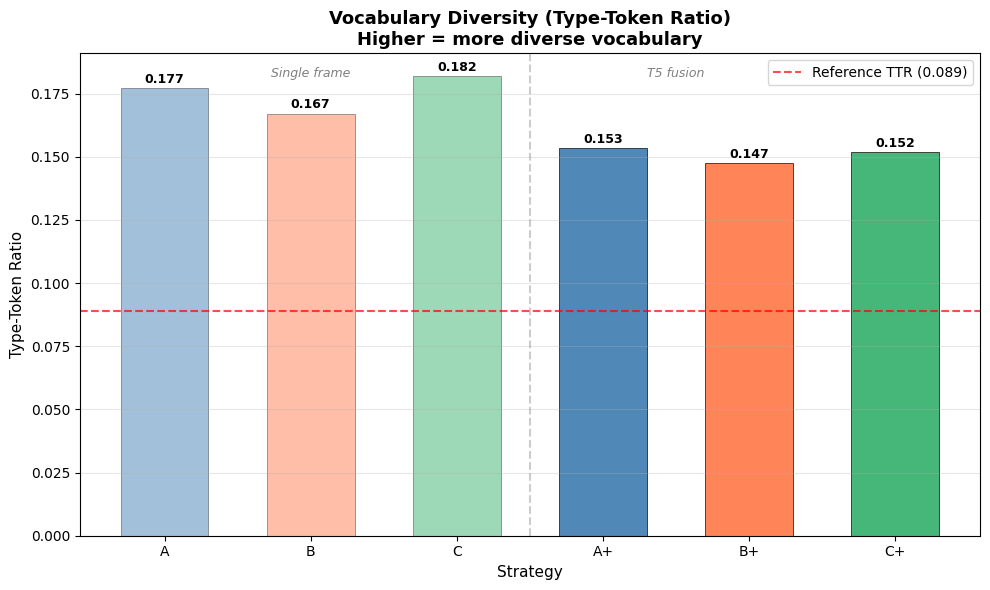

✅ Plot 2 saved: vocabulary_diversity.png


In [9]:
# ── Plot 1: Caption Length ─────────────────────────────────
fig1, ax = plt.subplots(figsize=(10, 6))

for i, (mean, std, col, al) in enumerate(zip(means, stds, colors, alphas)):
    ax.bar(i, mean, color=col, alpha=al, width=0.6,
           edgecolor='black', linewidth=0.5)
    ax.errorbar(i, mean, yerr=std, fmt='none',
                color='black', capsize=4, linewidth=1.5)
    ax.text(i, mean + std + 0.3, f'{mean:.1f}',
            ha='center', fontsize=9, fontweight='bold')

ax.axhline(y=np.mean(ref_lengths), color='red',
           linestyle='--', linewidth=1.5, alpha=0.7,
           label=f'Reference avg ({np.mean(ref_lengths):.1f})')
ax.set_xticks(range(len(short_names)))
ax.set_xticklabels(short_names)
ax.set_xlabel('Strategy', fontsize=11)
ax.set_ylabel('Average Caption Length (words)', fontsize=11)
ax.set_title('Average Caption Length per Strategy',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
ax.axvline(x=2.5, color='gray', linestyle='--', alpha=0.4)
ax.text(1.0, ax.get_ylim()[1]*0.95, 'Single frame',
        ha='center', fontsize=9, color='gray', style='italic')
ax.text(4.0, ax.get_ylim()[1]*0.95, 'T5 fusion',
        ha='center', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis-data/figures/'
            'caption_length.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Plot 1 saved: caption_length.png")

# ── Plot 2: Vocabulary Diversity ───────────────────────────
fig2, ax2 = plt.subplots(figsize=(10, 6))

ttrs = [vocab_stats[n]['ttr'] for n in names]
for i, (ttr, col, al) in enumerate(zip(ttrs, colors, alphas)):
    ax2.bar(i, ttr, color=col, alpha=al, width=0.6,
            edgecolor='black', linewidth=0.5)
    ax2.text(i, ttr + 0.002, f'{ttr:.3f}',
             ha='center', fontsize=9, fontweight='bold')

ax2.axhline(y=ref_ttr, color='red', linestyle='--',
            linewidth=1.5, alpha=0.7,
            label=f'Reference TTR ({ref_ttr:.3f})')
ax2.set_xticks(range(len(short_names)))
ax2.set_xticklabels(short_names)
ax2.set_xlabel('Strategy', fontsize=11)
ax2.set_ylabel('Type-Token Ratio', fontsize=11)
ax2.set_title('Vocabulary Diversity (Type-Token Ratio)\nHigher = more diverse vocabulary',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10)
ax2.grid(axis='y', alpha=0.3)
ax2.axvline(x=2.5, color='gray', linestyle='--', alpha=0.4)
ax2.text(1.0, ax2.get_ylim()[1]*0.95, 'Single frame',
         ha='center', fontsize=9, color='gray', style='italic')
ax2.text(3.5, ax2.get_ylim()[1]*0.95, 'T5 fusion',
         ha='center', fontsize=9, color='gray', style='italic')

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/thesis-data/figures/'
            'vocabulary_diversity.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Plot 2 saved: vocabulary_diversity.png")